In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import torch.optim
from torch.utils.data import DataLoader
%load_ext autoreload
%autoreload 2


In [2]:
#download  data
data = pd.read_csv('../data/train.csv')



# Exploration Data Analysis

In [3]:
print(data.shape)
print(data.info())
print(data.describe())
print(data.isnull().sum(axis=0))


(891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    

Датасет 891 семпл 12 признаков на каждый. Есть несколько категориальных/ординальных(Sex, Embarked, Pclass) и текстовых колонок(Name, Ticket, Cabin). Служебное поле PassangerID являющееся уникальным идентификатором пассажира. Среднее отклонение от признака к признаку разнится, возможно понадобится нормализовать данные. Наблюдаются null значения для колонок Cabin, Age, Embarked.


In [4]:
data["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

Распределение классов немного скошено, для валидации нужно будет стратификейтед к-фолд использовать

<Axes: >

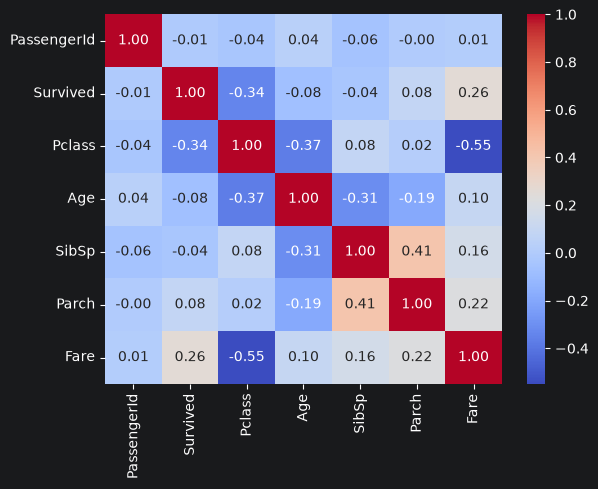

In [5]:
sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

Мультиколлинеарных зависимостей не найдено. Наблюдается слабо-умеренная корелляция признаков между собой оправданная доменной логикой ситуации. Умеренная корелляция Pclass и Fare, они отражают один и тот же сигнал богатства что логично.

In [6]:

from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

In [7]:
def validate(model, X, y):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model, X, y, cv=skf)

    return score


def get_skf():
    return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def split_data_pd(data: pd.DataFrame, target: str):
    X_data = data.drop(columns=target)
    y_data = data[target]

    return X_data, y_data


def split_data_np(data: pd.DataFrame, target: str):
    X_data = data.drop(columns=target).values
    y_data = data[target].values

    return X_data, y_data

In [8]:
df = data.copy()

## Data preprop

In [9]:
# Дропаем тексовые поля
'''
passanger id
Ticket
Cabin
name
Embarked
'''
df = df.drop(columns=["PassengerId", "Ticket", "Cabin", "Name", "Embarked"])

In [10]:
# Категоризируем пол через onehot
df = pd.get_dummies(df, columns=['Sex'], drop_first=True)

In [11]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male
0,0,3,22.0,1,0,7.2500,True
1,1,1,38.0,1,0,71.2833,False
2,1,3,26.0,0,0,7.9250,False
3,1,1,35.0,1,0,53.1000,False
4,0,3,35.0,0,0,8.0500,True


In [12]:
#заполняем пропуски Age
df.Age = df.Age.fillna(df.Age.mean())


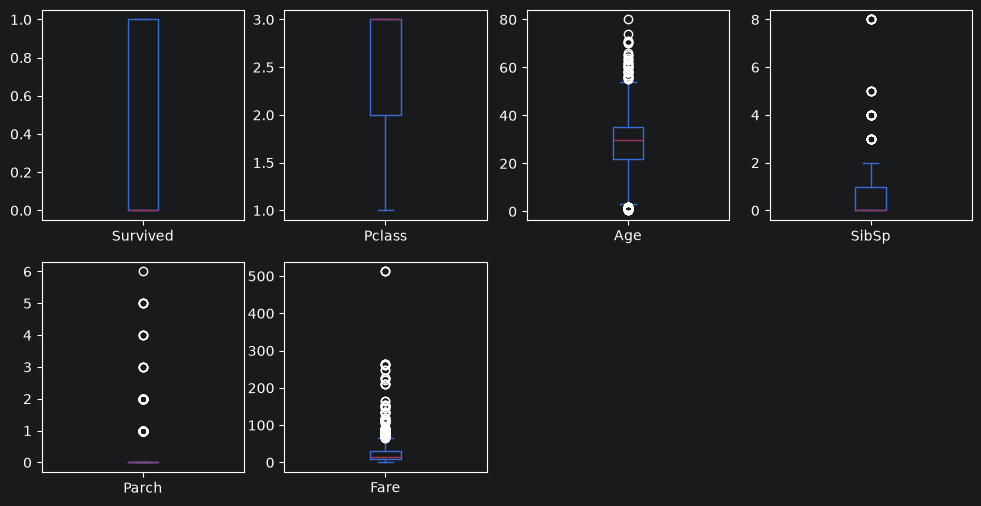

In [13]:
df.select_dtypes(include='number').plot(kind='box', subplots=True, layout=(2, 4), figsize=(12, 6))
plt.show()

у Fare и Age смещенные распределения, для линейных моделей их нужно будет логарифмировать

# Feature Engineering Experiments


 ### Идея 1

Извлечь буквенную часть из колонки Cabin и представить ее как некоторый категориальный признак удаленности пассажира от палубы со шлюпками.

In [14]:
featured_df = data.copy()

In [15]:
featured_df = pd.get_dummies(featured_df, columns=['Sex'], drop_first=True)
featured_df = featured_df.drop(columns=["PassengerId", "Ticket", "Name"])
featured_df.Age = featured_df.Age.fillna(featured_df.Age.mean())
featured_df["Embarked"] = featured_df["Embarked"].fillna(value='S')

In [16]:
featured_df.Age = featured_df.Age.fillna(featured_df.Age.mean())

In [17]:
import re

featured_df['Cabin'] = featured_df['Cabin'].apply(
    lambda x: re.sub(r'^([a-zA-Z]+).*', r'\1', x) if pd.notna(x) else 'Unknown')

In [18]:
featured_df.groupby("Cabin")["Survived"].agg(['mean', 'count'])

,mean,count
Cabin,,
A,0.466667,15
B,0.744681,47
C,0.593220,59
D,0.757576,33
E,0.750000,32
F,0.615385,13
G,0.500000,4
T,0.000000,1
Unknown,0.299854,687


<Axes: xlabel='Cabin', ylabel='count'>

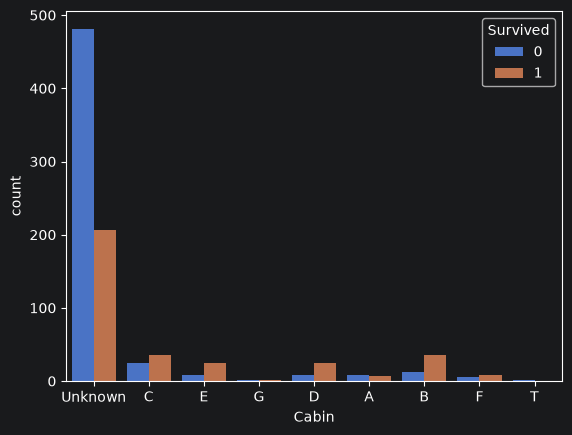

In [19]:
sns.countplot(x='Cabin', hue='Survived', data=featured_df)

Коэф выживаемости разнится от палубе к палубе в рамках первого класса, это значит что для тех 20% семплов для которых определен Cabin это даст доп точность, чтобы избежать оверфита на категории с малым числом примеров я их или объединю с ближайшими или затру.

In [20]:
featured_df = featured_df[(featured_df["Cabin"] != "T") & (featured_df["Cabin"] != "G")]
featured_df.head()


,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin,Embarked,Sex_male
0,0,3,22.0,1,0,7.2500,Unknown,S,True
1,1,1,38.0,1,0,71.2833,C,C,False
2,1,3,26.0,0,0,7.9250,Unknown,S,False
3,1,1,35.0,1,0,53.1000,C,S,False
4,0,3,35.0,0,0,8.0500,Unknown,S,True


# Идея 2
Интуитивно можно предположить что выживаемость зависит от размера семьи человека на борту И и от того как члены(семьи) физически раскиданы по кораблю.

In [21]:
### смотрим связь размера семьи с выживаемостью
featured_df['FamilySize'] = featured_df['SibSp'] + featured_df['Parch'] + 1

<Axes: xlabel='FamilySize', ylabel='Survived'>

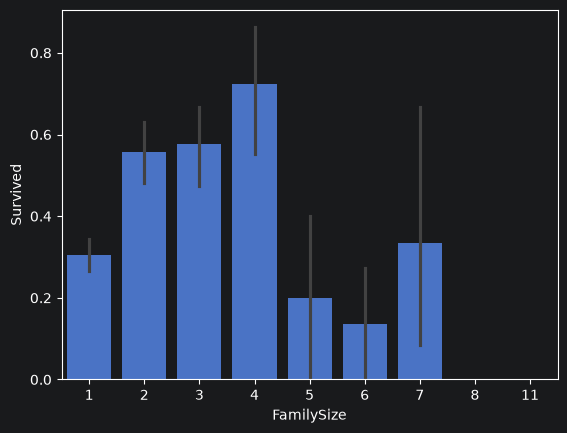

In [22]:
featured_df.groupby("FamilySize")["Survived"].agg(['mean', 'count'])
sns.barplot(x='FamilySize', y='Survived', data=featured_df)

Действительно есть зависимость между количеством детей и шансом выжить нелинейной формы, до +-4 детей с ростом кол-ва детей шанс выжить растет затем падает. Этот датасет будет использоваться только в деревьях, значит биниризируют пороги деревья сами. Новый признак полезен.

Для пассажиров 2 и 3 класса нет информации о физическом расположении по каютам, гипотезу отметаем. Однако есть мысль что может быть корелляция между буквенной категорией билета и выживаемостью.

In [24]:
#df[df['Pclass'] == 1].groupby(df['Ticket_Prefix'] == 'PC')['Survived'].mean()


Гипотеза не подтвердилась, при стратифицированном анализе значительных перекосов нет.

In [25]:

featured_df["Embarked"] = featured_df["Embarked"].fillna(value='S')

In [26]:
featured_df = featured_df.drop(columns=['Embarked'])

In [27]:
featured_df = pd.get_dummies(data=featured_df, columns=["Cabin"])

## **Тренировка и подбор параметров**

### Линейная регрессия

In [28]:
#baseline: логистическая регрессия без гп и нормализации
score = validate(LogisticRegression(max_iter=1000), *split_data_np(featured_df, "Survived"))

In [29]:
print(score.mean())
print(score.std())

0.8024757189106836
0.017939291851321905


In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=100, penalty='l2', C=.1)),
])

score = validate(pipe, *split_data_np(featured_df, "Survived"))

E:\d_temp\pp\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
E:\d_temp\pp\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
E:\d_temp\pp\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1

In [31]:
print(score.mean())
print(score.std())

0.801339427410652
0.01884724539999177


In [32]:
dflog = featured_df.copy()
dflog["Fare"] = np.log1p(dflog["Fare"])


### KNN

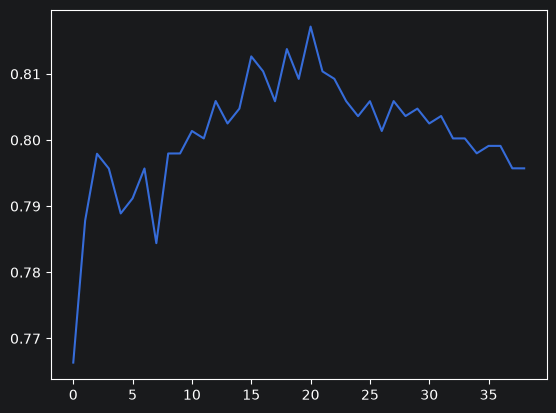

In [33]:

scores = []
max_score = 0
max_n = 0
for n in np.arange(1, 40, 1):

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=n, weights='uniform', algorithm='auto')),
    ])

    score = validate(pipe, *split_data_np(dflog, "Survived"))

    scores.append(score.mean())

    if score.mean() > max_score:
        max_score = score.mean()
        max_n = n

plt.plot(scores)
plt.show()





In [34]:
print(max_score)

0.8171522884529931


### Решающее дерево

In [35]:
from sklearn.model_selection import GridSearchCV

param_grid = {"max_depth": [4, 6, 9], "random_state": [42], "min_samples_leaf": [1, 5, 10]}
g = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=param_grid, cv=get_skf(), n_jobs=-1)
g.fit(*split_data_np(df, "Survived"))

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [4, 6, ...], 'min_samples_leaf': [1, 5, ...], 'random_state': [42]}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, def

In [36]:
print(f"Лучший скор {g.best_score_}")

Лучший скор 0.8372795179210344


### Random Forest

In [37]:
featured_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,FamilySize,Cabin_A,Cabin_B,Cabin_C,Cabin_D,Cabin_E,Cabin_F,Cabin_Unknown
0,0,3,22.0,1,0,7.2500,True,2,False,False,False,False,False,False,True
1,1,1,38.0,1,0,71.2833,False,2,False,False,True,False,False,False,False
2,1,3,26.0,0,0,7.9250,False,1,False,False,False,False,False,False,True
3,1,1,35.0,1,0,53.1000,False,2,False,False,True,False,False,False,False
4,0,3,35.0,0,0,8.0500,True,1,False,False,False,False,False,False,True


In [38]:
models = [RandomForestClassifier(n_estimators=100, n_jobs=-1, max_depth=9, random_state=42),
          RandomForestClassifier(n_estimators=350, n_jobs=-1, max_depth=7, random_state=42, max_samples=0.9,
                                 min_samples_split=2, max_features=7),
          RandomForestClassifier(n_estimators=150, n_jobs=-1, max_depth=13, random_state=42)]

scores = []

best_var = {"m": None, "score mean": 0}
for m in models:
    score = validate(m, *split_data_np(featured_df, "Survived"))
    scores.append({"score mean": score.mean(), "score std": score.std(), "model": m})
    if best_var["score mean"] < score.mean():
        best_var["m"] = m
        best_var["score mean"] = score.mean()



In [39]:
print(f" best score : {best_var['score mean']}, model : {best_var['m']}")

 best score : 0.8340887450009522, model : RandomForestClassifier(max_depth=9, n_jobs=-1, random_state=42)


In [40]:
scores

[{'score mean': np.float64(0.8340887450009522),
  'score std': np.float64(0.015782944148912167),
  'model': RandomForestClassifier(max_depth=9, n_jobs=-1, random_state=42)},
 {'score mean': np.float64(0.8216593664698788),
  'score std': np.float64(0.01852591395828881),
  'model': RandomForestClassifier(max_depth=7, max_features=7, max_samples=0.9,
                         n_estimators=350, n_jobs=-1, random_state=42)},
 {'score mean': np.float64(0.8273217799784168),
  'score std': np.float64(0.022131103061428563),
  'model': RandomForestClassifier(max_depth=13, n_estimators=150, n_jobs=-1,
                         random_state=42)}]

# Бустинги


### CatBoost

In [41]:

from sklearn.model_selection import KFold
from catboost import CatBoostClassifier, Pool
import numpy as np

cat_features = ["Sex_male"]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []
X = featured_df.drop(columns="Survived")
y = featured_df["Survived"]

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    train_pool = Pool(X_train, y_train, cat_features=cat_features)
    val_pool = Pool(X_val, y_val, cat_features=cat_features)

    model = CatBoostClassifier(
        iterations=250,
        learning_rate=0.073,
        depth=3,
        verbose=0,
        l2_leaf_reg=5
    )
    model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=50)

    score = model.score(X_val, y_val)  # accuracy по умолчанию
    scores.append(score)
    print(f"Fold {fold + 1}: {score:.4f}")

print(f"\nСредний score: {np.mean(scores):.4f} ± {np.std(scores):.4f}")


Fold 1: 0.8315
Fold 2: 0.8644
Fold 3: 0.8531
Fold 4: 0.8136
Fold 5: 0.8136

Средний score: 0.8352 ± 0.0206


### XGBoost

In [42]:
import xgboost as xgb

param_grid = {
    'n_estimators': [180, 200, 300, 150, 100, 50],
    'max_depth': [3, 5, 6, None, 7],
    'learning_rate': [0.07, 0.03, 0.09, 0.1, 0.05, 0.3, 0.44]
}

#model = xgb.XGBClassifier(n_estimators=180, n_jobs=-1, max_depth=5, random_state=42, learning_rate=0.07)
model = xgb.XGBClassifier(random_state=412)
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=get_skf(), n_jobs=-1)
score = grid.fit(*split_data_np(df, "Survived"))

print(f"\n Лучший score: {grid.best_score_}")
print(f"\n Лучшие параметры: {grid.best_params_}")
#print(f'Результаты {grid.cv_results_}')


 Лучший score: 0.8506998932898122

 Лучшие параметры: {'learning_rate': 0.07, 'max_depth': 5, 'n_estimators': 200}


In [43]:
model = xgb.XGBClassifier(random_state=12, learning_rate=0.07, max_depth=5, n_estimators=200)

In [44]:
model.fit(*split_data_np(df, "Survived"))

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [45]:
model.feature_importances_

array([0.20287685, 0.02991188, 0.05799815, 0.01813377, 0.03139332,
       0.659686  ], dtype=float32)

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Age       891 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Sex_male  891 non-null    bool   
dtypes: bool(1), float64(2), int64(4)
memory usage: 42.8 KB


По важности признаков видно что модель часто отдает предпочтение признаку пола, что сходится с логикой ситуации датасета, и так же объясняет почему при сильном уменьшении кол ва деревьев и их глубины точность падает не сильно, тк по чистоте сплит на основе Sex самый выйгрышный признак, и дерево всегда берет его.

### LGBM

In [47]:

from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

X = df.drop('Survived', axis=1)
y = df['Survived']

lgbm = LGBMClassifier(num_leaves=5, min_data_in_leaf=25, learning_rate=0.04, n_estimators=250, n_jobs=-1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=5472)
scores = cross_val_score(lgbm, X, y, cv=cv, scoring='accuracy')

print(f"Средний score: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000082 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 202
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignore

Самая лучшая и стабильная метрика по итогу у CatBoost

# DNN


In [48]:
from dnn import Trainer, DNNClassifier, DataManager


In [126]:
dataset = DataManager.CustomDataset(*split_data_pd(df, "Survived"))
from torch.utils.data import Subset

from torch.utils.data import SubsetRandomSampler, SequentialSampler
import torch.nn as nn

indices = list(range(len(dataset)))
np.random.shuffle(indices)

total_size = len(dataset)

train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
#test_size = total_size - train_size - val_size

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]

train_sampler = SubsetRandomSampler(train_indices)

train_loader = DataLoader(dataset, batch_size=32, sampler=train_sampler)
val_dataset = Subset(dataset, val_indices)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
#test_loader = DataLoader(dataset=dataset, batch_size=32, shuffle=False, num_workers=-1, pin_memory=True, sampler=)


In [125]:
model = DNNClassifier(input_dim=df.shape[1] - 1, hidden_size=50, output_dim=2)

trainer = Trainer(model=model, optimizer=torch.optim.Adam(params=model.parameters(), lr=0.05))

loss_history, train_metrics_history, val_metric_history, last_saved_best_metric = trainer.fit(epochs=120,
                                                                                              train_loader=train_loader,
                                                                                              val_loader=val_loader,
                                                                                              validating=True,
                                                                                              device='cpu',
                                                                                              train_metric_accumulating=1)



Epoch: 0, Loss: 0.6556253433227539, Batch_Accuracy: 0.71875
Epoch: 0, Loss: 0.6501659154891968, Batch_Accuracy: 0.78125
Epoch: 0, Loss: 0.7309684753417969, Batch_Accuracy: 0.65625
Epoch: 0, Loss: 0.44818243384361267, Batch_Accuracy: 0.8125
Epoch: 0, Loss: 0.9107760787010193, Batch_Accuracy: 0.59375
Epoch: 0, Loss: 0.8537557721138, Batch_Accuracy: 0.5
Epoch: 0, Loss: 0.3271488547325134, Batch_Accuracy: 0.875
Epoch: 0, Loss: 0.49399280548095703, Batch_Accuracy: 0.8125
Epoch: 0, Loss: 0.5528207421302795, Batch_Accuracy: 0.8125
Epoch: 0, Loss: 0.4582229256629944, Batch_Accuracy: 0.8125
Epoch: 0, Loss: 0.49694010615348816, Batch_Accuracy: 0.78125
Epoch: 0, Loss: 0.7917031049728394, Batch_Accuracy: 0.75
Epoch: 0, Loss: 0.5422106385231018, Batch_Accuracy: 0.78125
Epoch: 0, Loss: 0.4858541786670685, Batch_Accuracy: 0.75
Epoch: 0, Loss: 0.6910848021507263, Batch_Accuracy: 0.71875
Epoch: 0, Loss: 0.5529547929763794, Batch_Accuracy: 0.8125
Epoch: 0, Loss: 0.34759384393692017, Batch_Accuracy: 0.84

KeyboardInterrupt: 

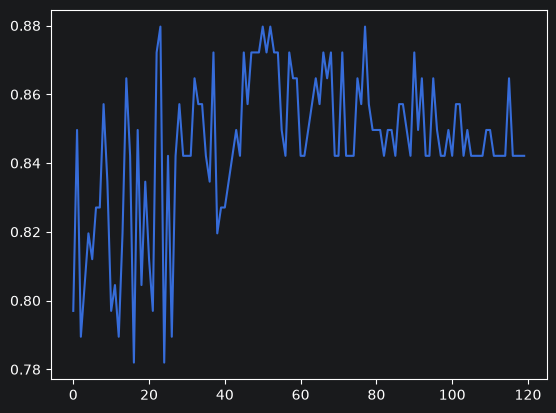

In [105]:
plt.plot(val_metric_history)

In [106]:
last_saved_best_metric

{'metric': 0.8796992481203008, 'epoch': 23}

In [129]:
def cv_score(dataset, input_dim, k=5, batch_size=32, epochs=120):

    y = dataset.labels  # numpy array

    kfold = StratifiedKFold(n_splits=k, shuffle=True, random_state=562)
    scores = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(dataset.features, y)):
        train_loader = DataLoader(Subset(dataset, train_idx), batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(Subset(dataset, val_idx), batch_size=batch_size, shuffle=False)

        model = DNNClassifier(input_dim=input_dim, hidden_size=50, output_dim=2)
        optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

        trainer = Trainer(model=model, optimizer=optimizer)
        _, _, val_metric_history, b = trainer.fit(
            epochs=epochs,
            train_loader=train_loader,
            val_loader=val_loader,
            validating=True,
            device='cpu'
        )

        scores.append(b["metric"])
        print(f"Fold {fold+1}: {b["metric"]}")

    print(f"\nMean: {np.mean(scores)} ± {np.std(scores)}")
    return scores

In [131]:
scores = cv_score(dataset, input_dim=df.shape[1] - 1)

Epoch: 0, Loss: 0.8698152899742126, Batch_Accuracy: 0.40625
Epoch: 0, Loss: 0.8007241487503052, Batch_Accuracy: 0.40625
Epoch: 0, Loss: 0.8064528107643127, Batch_Accuracy: 0.53125
Epoch: 0, Loss: 0.7281074523925781, Batch_Accuracy: 0.59375
Epoch: 0, Loss: 0.6845800876617432, Batch_Accuracy: 0.53125
Epoch: 0, Loss: 0.7407413721084595, Batch_Accuracy: 0.53125
Epoch: 0, Loss: 0.6921036839485168, Batch_Accuracy: 0.5625
Epoch: 0, Loss: 0.8482874035835266, Batch_Accuracy: 0.5
Epoch: 0, Loss: 0.6778879761695862, Batch_Accuracy: 0.625
Epoch: 0, Loss: 0.775836169719696, Batch_Accuracy: 0.59375
Epoch: 0, Loss: 0.6229680776596069, Batch_Accuracy: 0.6875
Epoch: 0, Loss: 0.5658191442489624, Batch_Accuracy: 0.6875
Epoch: 0, Loss: 0.7436583042144775, Batch_Accuracy: 0.53125
Epoch: 0, Loss: 0.629197895526886, Batch_Accuracy: 0.65625
Epoch: 0, Loss: 0.6538019180297852, Batch_Accuracy: 0.65625
Epoch: 0, Loss: 0.5899481177330017, Batch_Accuracy: 0.8125
Epoch: 0, Loss: 0.6192022562026978, Batch_Accuracy: 

# Stacking

In [139]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


base_estimators = [
    ('knn', KNeighborsClassifier(n_neighbors=10)),
    ('svc', SVC(probability=True)),
    ('tree', DecisionTreeClassifier(max_depth=5, random_state=42, min_samples_leaf=5))
]


meta_model = LogisticRegression()

stack = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_model,
    cv=5,
    stack_method='auto',
    n_jobs=-1
)

score = validate(stack, *split_data_np(dflog, "Survived"))
print(f"Средний score: {np.mean(score):.4f} ± {np.std(score):.4f}")

Средний score: 0.8160 ± 0.0195


In [140]:

from sklearn.ensemble import VotingClassifier


estimators = [
    ('lr', LogisticRegression()),
    ('knn', KNeighborsClassifier()),
    ('svc', SVC(probability=True))
]

voting = VotingClassifier(
    estimators=estimators,
    voting='soft',   # или 'hard'
    weights=None,    # можно задать веса моделям, например [2, 1, 1]
    n_jobs=-1
)

score = validate(voting, *split_data_np(dflog, "Survived"))
print(f"Средний score: {np.mean(score):.4f} ± {np.std(score):.4f}")

Средний score: 0.8115 ± 0.0222
